# Feasibility Verification: C-MICL vs. Standard MICL

This notebook builds on *01_conformal_tutorial.ipynb (regression)* and
*02_uncertainty_integration.ipynb (regression)*, where we calibrated a neural network
surrogate together with a residual-scale model to construct conformal prediction
intervals. Here we use that same machinery to design a chemical reactor under
uncertainty, following the *Conformal Mixed-Integer Constraint Learning* (C-MICL)
framework, and check whether the resulting designs are *actually* feasible using a
physics-based simulation.

In Mixed-Integer Constraint Learning (MICL), a learned model $\widehat{h}(x)$ is
embedded directly into an optimization problem in place of an unknown or expensive true
function $h(x)$, by constraining $\widehat{h}(x) \in \mathcal{Y}$ for some target set
$\mathcal{Y}$. Because $\widehat{h}$ is only an approximation of $h$, a solution that is
feasible with respect to $\widehat{h}$ need not be feasible with respect to the true
function $h$, a property the C-MICL paper calls **ground-truth feasibility**: a solution
$x'$ is ground-truth feasible if $h(x') \in \mathcal{Y}$.

C-MICL instead constrains a conformal prediction set, $\mathcal{C}_\alpha(x) \subseteq
\mathcal{Y}$, rather than the point prediction $\widehat{h}(x)$ itself. We compare the two
strategies here:

- **MICL (standard)**: a single point-prediction neural network $\widehat{h}(x)$
  plugged directly into the optimization model, with no uncertainty quantification.
- **C-MICL (conformal)**: a mean-prediction network together with a calibrated
  residual-scale network, requiring the conformal prediction set to remain within
  $\mathcal{Y}$.

## Motivating Example: Membrane Reactor Design

We consider the design of a differential membrane reactor that converts benzene
precursors into benzene ($\text{C}_6\text{H}_6$). Five design variables (feed rate,
helium sweep rate, temperature, tube diameter, and tube length) determine the reactor's
performance, governed by a system of ODEs along the reactor length. Training data was
generated by simulating this ODE system at randomly sampled design points, with noise
added to mimic real measurement error.

For each of several randomly generated cost vectors, we minimize cost subject to a
minimum benzene production requirement (the set $\mathcal{Y} = [50, \infty)$), using a
neural network surrogate in place of the expensive ODE simulation. We then check the
resulting design against the *true* ODE model $h(x)$: is the chosen design
ground-truth feasible, or did the surrogate's error mislead the optimizer into
selecting an infeasible design?


## When Does C-MICL Guarantee Ground-Truth Feasibility?

*Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees* shows that
any feasible solution to the C-MICL problem is ground-truth feasible with probability
at least $1 - \alpha$,

$$
\mathbb{P}\left( h(x') \in \mathcal{Y} \mid (x', z') \in \mathcal{F}_N \right) \ge 1 - \alpha,
$$

where $\mathcal{F}_N$ is the feasible region of the C-MICL problem. This is the formal
guarantee this notebook empirically illustrates. It does **not** hold unconditionally:
the paper's theorem requires two conditions to hold.

1. **Ground-Truth Feasibility Conformal Coverage Guarantee** (Lemma): the conformal
   sets must provide *conditional* coverage given the true feasibility status of a
   point, not just marginal coverage,
   $$
   \mathbb{P}(Y \in \mathcal{C}_\alpha(X) \mid Y \in \mathcal{Y}) \ge 1-\alpha,
   \qquad
   \mathbb{P}(Y \in \mathcal{C}_\alpha(X) \mid Y \notin \mathcal{Y}) \ge 1-\alpha.
   $$
   This is achieved by constructing the conformal sets via *Mondrian* conformal
   prediction, calibrated separately within each group.

2. **Conditional Independence of Feasibility and Coverage** (Assumption): whether a
   point is C-MICL feasible (i.e., $(x', z') \in \mathcal{F}_N$) must be conditionally
   independent of whether its conformal set covers the true value, given the point's
   ground-truth feasibility status. Informally, the optimizer's choice of $x'$ must not
   systematically bias coverage within the feasible region it selects from.

For simplicity, this notebook calibrates a single (non-Mondrian) conformal set, as in
*01_conformal_tutorial.ipynb (regression)*, rather than the Mondrian construction the
Lemma calls for. Both conditions above are **assumptions**, and how closely they hold
in a given setting is exactly what determines how the empirical feasibility rate
relates to the nominal $1-\alpha$ target, whether it falls short of, lands on, or
comfortably exceeds it within a given sample. We check, over 20 random optimization
instances, whether the resulting C-MICL designs are ground-truth feasible more often
than their MICL counterparts.


## Library Setup

This notebook requires the following Python packages:
- `numpy`, `pandas`: data manipulation
- `matplotlib`, `seaborn`: plotting
- `scipy`: integrating the ODE system used as the feasibility oracle, and computing
  confidence intervals
- `keras`: training the mean and residual-scale surrogate networks
- `pyomo`: the algebraic modeling language used to define the optimization model
- `omlt`: embedding the trained networks into the Pyomo model

**NOTE:** This notebook requires a working MIP solver (e.g., CBC, Gurobi). The
open-source solver CBC is used by default.


In [1]:
import contextlib
import os

import numpy as np


@contextlib.contextmanager
def _suppress_native_stderr():
    """Suppress the native TensorFlow/CUDA plugin-registration banner on import.

    This noise is emitted by C++ static initializers before Python-level log
    settings (e.g. TF_CPP_MIN_LOG_LEVEL) take effect, so it has to be silenced
    at the OS file-descriptor level instead.
    """
    fd = os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 2)
    try:
        yield
    finally:
        os.dup2(fd, 2)
        os.close(devnull)
        os.close(fd)


os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
with _suppress_native_stderr():
    # neural network training
    import keras
    from keras.layers import Dense, Input
    from keras.models import Sequential

    # Keras lazily probes for CUDA devices on the first fit/predict call, which
    # re-emits the same native banner outside of this suppressed block. Warming
    # that probe up here, while still suppressed, makes later cells silent.
    _warmup = Sequential([Input(shape=(1,)), Dense(1)])
    _warmup.compile(optimizer="adam", loss="mse")
    _warmup.fit(
        np.zeros((1, 1)),
        np.zeros((1, 1)),
        epochs=1,
        verbose=0,
    )

# data manipulation and plotting
import matplotlib.pyplot as plt
import pandas as pd

# optimization
import pyomo.environ as pyo
import seaborn as sns

# ODE integration for the feasibility oracle
from scipy import stats
from scipy.integrate import odeint

# OMLT: embedding neural networks in optimization
from omlt import OmltBlock
from omlt.io.keras import keras_reader
from omlt.neuralnet import ReluBigMFormulation

keras.utils.set_random_seed(0)

## Dataset

The dataset contains 2000 simulated design points: five inputs
(`v0`, `v_He`, `T`, `dt`, `L`) and the resulting benzene production rate `F_C6H6`
(mg/s), with noise added to the simulated output. We rescale inputs and the output to
keep the surrogate's training data on comparable numerical scales.


In [2]:
df = pd.read_csv("../../data/membrane_reactor_data.csv")

independent_vars = ["v0", "v_He", "T", "dt", "L"]
dependent_var = "F_C6H6"

# Rescale inputs and output to comparable numerical ranges. This is a naive
# scaling (divide by a fixed constant), not a learned normalization; `dt` is
# left unscaled since it is already on the order of 1 (tube diameter in cm).
# We later multiply optimized designs by 100 to undo this scaling before
# evaluating the true ODE oracle, which expects the original units.
df[independent_vars] = df[independent_vars] / 100
df[dependent_var] = df[dependent_var] / 10
df["dt"] = df["dt"] * 100

X = df[independent_vars].to_numpy()
y = df[[dependent_var]].to_numpy()

n = len(df)
rng = np.random.default_rng(42)
idx = rng.permutation(n)

train_end = int(0.7 * n)
cal_end = int(0.85 * n)

train_idx = idx[:train_end]
cal_idx = idx[train_end:cal_end]
test_idx = idx[cal_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_cal, y_cal = X[cal_idx], y[cal_idx]

print(f"Train size: {len(X_train)}, calibration size: {len(X_cal)}")

Train size: 1400, calibration size: 300


## Training the Mean and Residual-Scale Surrogates

As in *02_uncertainty_integration.ipynb (regression)*, we train two networks:
- $\widehat{f}(x)$: predicts the mean benzene production rate.
- $\widehat{u}(x)$: predicts the scale of $\widehat{f}$'s absolute residual.

The MICL strategy below uses only $\widehat{f}$; the C-MICL strategy uses both.


In [3]:
def build_mlp(input_dim):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model


f_model = build_mlp(X_train.shape[1])
f_model.fit(X_train, y_train, epochs=300, batch_size=32, verbose=0)

train_residuals = np.abs(y_train - f_model.predict(X_train, verbose=0))

u_model = build_mlp(X_train.shape[1])
u_model.fit(X_train, train_residuals, epochs=300, batch_size=32, verbose=0)

## Calibrating the Conformal Quantile

We compute normalized residuals on the calibration set,
$ s_i = |y_i - \widehat{f}(x_i)| / \widehat{u}(x_i) $, and take the
$(1-\alpha)$ quantile with the usual finite-sample correction. We use
$\alpha = 0.1$ throughout this notebook; other values can be explored by changing this
one parameter.


In [4]:
alpha = 0.1

u_cal_pred = np.maximum(u_model.predict(X_cal, verbose=0), 1e-6)
f_cal_pred = f_model.predict(X_cal, verbose=0)
s = np.abs(y_cal - f_cal_pred) / u_cal_pred

n_cal = len(s)
qhat = np.quantile(
    s,
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
    method="higher",
)
print(f"Conformal quantile q_(1-alpha): {qhat:.3f}")

Conformal quantile q_(1-alpha): 2.292


## The Feasibility Oracle

The reactor's true behavior is governed by a system of ODEs describing reaction and
membrane permeation along the tube length. We integrate this system directly (with
`scipy.integrate.odeint`) to evaluate the *true* benzene production rate for any design,
independent of the neural network surrogates above. This oracle is only used to verify
designs after optimization, never inside the optimization model itself.


In [5]:
def membrane_reactor_odes(flows, _length, params):
    """Right-hand side of the differential membrane reactor model."""
    dt, _v_he, v0, f_he, ft0 = params
    gas_constant = 8.314e6
    k1, k1_inv = 0.04, 6.40e6
    k2, k2_inv = 4.20, 56.38
    permeation_coeff = 3600 * 0.01e-4
    selectivity = 1500
    pt = ps = 101325.0

    tube_area = 0.25 * np.pi * (dt**2)
    flows = np.where(flows <= 1e-9, 1e-9, flows)

    tube_flow = flows[0:4].sum()
    shell_flow = flows[4:].sum() + f_he
    volume = v0 * (tube_flow / ft0)
    conc = flows[:4] / volume

    p0t, p1t, p2t, p3t = (pt / 101325) * (flows[0:4] / tube_flow)
    p0s, p1s, p2s, p3s = (ps / 101325) * (flows[4:] / shell_flow)

    r0 = (
        3600
        * k1
        * conc[0]
        * (1 - ((k1_inv * conc[1] * conc[2] ** 2) / (k1 * conc[0] ** 2)))
    )
    r0 = np.where(conc[0] <= 1e-9, 0, r0)

    r1 = (
        3600
        * k2
        * conc[1]
        * (1 - ((k2_inv * conc[3] * conc[2] ** 3) / (k2 * conc[1] ** 3)))
    )
    r1 = np.where(conc[1] <= 1e-9, 0, r1)

    catalyst = (1 - 0.5) * 0.9  # (1 - void fraction) * effectiveness

    return np.array(
        [
            -catalyst * r0 * tube_area
            - (permeation_coeff / selectivity) * (p0t**0.25 - p0s**0.25) * np.pi * dt,
            0.5 * catalyst * r0 * tube_area
            - catalyst * r1 * tube_area
            - (permeation_coeff / selectivity) * (p1t**0.25 - p1s**0.25) * np.pi * dt,
            catalyst * r0 * tube_area
            + catalyst * r1 * tube_area
            - permeation_coeff * (p2t**0.25 - p2s**0.25) * np.pi * dt,
            (1 / 3) * catalyst * r1 * tube_area
            - (permeation_coeff / selectivity) * (p3t**0.25 - p3s**0.25) * np.pi * dt,
            (permeation_coeff / selectivity) * (p0t**0.25 - p0s**0.25) * np.pi * dt,
            (permeation_coeff / selectivity) * (p1t**0.25 - p1s**0.25) * np.pi * dt,
            permeation_coeff * (p2t**0.25 - p2s**0.25) * np.pi * dt,
            (permeation_coeff / selectivity) * (p3t**0.25 - p3s**0.25) * np.pi * dt,
        ]
    )


def true_benzene_production(v0, v_he, temperature, dt, length):
    """Integrate the ODE system and return the true benzene production rate (mg/s)."""
    gas_constant = 8.314e6
    benzene_mw = 78.00
    pt = ps = 101325.0

    ft0 = pt * v0 / (gas_constant * temperature)
    f_he = ps * v_he / (gas_constant * temperature)

    initial_flows = np.hstack((ft0, np.zeros(7)))
    z_span = np.linspace(0, length, 2000)

    flows = odeint(
        membrane_reactor_odes,
        initial_flows,
        z_span,
        args=((dt, v_he, v0, f_he, ft0),),
        rtol=1e-10,
        atol=1e-10,
    )
    return float(flows[-1, 3] * 1000 * benzene_mw)

## The Base Optimization Model

We define the design optimization problem: minimize cost subject to standard
engineering bounds relating the five design variables, plus a minimum benzene
production requirement that will be enforced through a surrogate model.


In [6]:
design_vars = ["v0", "v_He", "T", "dt", "L"]
min_req = 5.0  # scaled units; equivalent to 50 mg/s in the original data scale


def build_base_model(cost):
    m = pyo.ConcreteModel()
    m.I = pyo.Set(initialize=design_vars)
    m.mapper = {idx: pos for pos, idx in enumerate(design_vars)}
    m.x = pyo.Var(m.I, within=pyo.NonNegativeReals)

    @m.Objective(sense=pyo.minimize)
    def obj(m):
        return sum(cost[m.mapper[i]] * m.x[i] for i in m.I)

    @m.Constraint()
    def geometry_ub(m):
        return m.x["L"] <= 1.5 * m.x["dt"]

    @m.Constraint()
    def geometry_lb(m):
        return m.x["L"] >= 0.1 * m.x["dt"]

    @m.Constraint()
    def gasrate_ub(m):
        return m.x["v0"] <= 3 * m.x["v_He"]

    @m.Constraint()
    def gasrate_lb(m):
        return m.x["v0"] >= 0.75 * m.x["v_He"]

    @m.Constraint()
    def residence_ub(m):
        return m.x["v0"] <= 120 * m.x["L"]

    @m.Constraint()
    def residence_lb(m):
        return m.x["v0"] >= 20 * m.x["L"]

    @m.Constraint()
    def flow_bound_high_t(m):
        return m.x["v0"] <= 1.1 * m.x["T"]

    return m


input_bounds = list(zip(X_train.min(axis=0), X_train.max(axis=0)))

## MICL: Embedding the Point-Prediction Surrogate

The standard MICL strategy embeds only $\widehat{f}$, requiring its prediction to
meet the production target directly: $\widehat{f}(x) \ge \text{min\_req}$. This is
the $\widehat{h}(x) \in \mathcal{Y}$ constraint from the MICL formulation, with no
uncertainty quantification.


In [7]:
def build_micl_model(cost):
    m = build_base_model(cost)

    f_net = keras_reader.load_keras_sequential(f_model, None, input_bounds)
    m.f_surrogate = OmltBlock()
    m.f_surrogate.build_formulation(ReluBigMFormulation(f_net))

    m.y = pyo.Var()

    @m.Constraint(m.I)
    def connect_inputs(m, i):
        return m.x[i] == m.f_surrogate.inputs[m.mapper[i]]

    @m.Constraint()
    def connect_outputs(m):
        return m.y == m.f_surrogate.outputs[0]

    @m.Constraint()
    def meet_spec(m):
        return m.y >= min_req

    return m

## C-MICL: Embedding the Calibrated Surrogate Pair

The C-MICL strategy embeds both $\widehat{f}$ and $\widehat{u}$, and constrains the
conformal prediction set $\mathcal{C}_\alpha(x) = [\widehat{f}(x) \pm
\widehat{q}_{1-\alpha}\,\widehat{u}(x)]$ to lie within $\mathcal{Y} = [50, \infty)$,
which reduces to requiring the *lower edge* of the band to meet the production
target: $\widehat{f}(x) - \widehat{q}_{1-\alpha}\,\widehat{u}(x) \ge \text{min\_req}$.


In [8]:
def build_c_micl_model(cost):
    m = build_base_model(cost)

    f_net = keras_reader.load_keras_sequential(f_model, None, input_bounds)
    u_net = keras_reader.load_keras_sequential(u_model, None, input_bounds)
    m.f_surrogate = OmltBlock()
    m.u_surrogate = OmltBlock()
    m.f_surrogate.build_formulation(ReluBigMFormulation(f_net))
    m.u_surrogate.build_formulation(ReluBigMFormulation(u_net))

    m.y_f = pyo.Var()
    m.y_u = pyo.Var(within=pyo.NonNegativeReals)

    @m.Constraint(m.I)
    def f_connect_inputs(m, i):
        return m.x[i] == m.f_surrogate.inputs[m.mapper[i]]

    @m.Constraint()
    def f_connect_outputs(m):
        return m.y_f == m.f_surrogate.outputs[0]

    @m.Constraint(m.I)
    def u_connect_inputs(m, i):
        return m.x[i] == m.u_surrogate.inputs[m.mapper[i]]

    @m.Constraint()
    def u_connect_outputs(m):
        return m.y_u == m.u_surrogate.outputs[0]

    @m.Constraint()
    def meet_spec(m):
        return m.y_f - qhat * m.y_u >= min_req

    return m

## Comparing Ground-Truth Feasibility Rates

For 20 randomly generated cost vectors, we solve both the MICL and C-MICL models,
then check each resulting design against the true ODE oracle $h(x)$: is the design
ground-truth feasible ($h(x) \ge 50$ mg/s, the unscaled equivalent of `min_req`), or
did the surrogate mislead the optimizer?


In [9]:
import logging

# OMLT's Big-M formulation initializes internal surrogate variables to 0 before the
# solver assigns real values; since these variables' computed bounds (derived from the
# training data's range) never include 0, this benign initialization step otherwise
# logs a Pyomo W1002 warning on every model build below.
logging.getLogger("pyomo.core").setLevel(logging.ERROR)

solver = pyo.SolverFactory("cbc")
iterations = 20
rng_cost = np.random.default_rng(0)

results_log = []

for i in range(iterations):
    cost = rng_cost.uniform(-4, 4, size=5)
    cost[cost < 0] /= 10

    for strategy, build_fn in [
        ("MICL", build_micl_model),
        ("C-MICL", build_c_micl_model),
    ]:
        m = build_fn(cost)
        res = solver.solve(m, tee=False)

        x_val = m.x.extract_values()
        true_production = true_benzene_production(
            x_val["v0"]
            * 100,  # undo the naive /100 input scaling (see Dataset section)
            x_val["v_He"] * 100,
            x_val["T"] * 100,
            x_val["dt"],
            x_val["L"] * 100,
        )

        results_log.append(
            {
                "iteration": i,
                "strategy": strategy,
                "termination": str(res.solver.termination_condition),
                "objective": pyo.value(m.obj),
                "true_production": true_production,
                "truly_feasible": true_production >= 50,
            }
        )

results_df = pd.DataFrame(results_log)
results_df.head()

,iteration,strategy,termination,objective,true_production,truly_feasible
0,0,MICL,optimal,3.657015,46.987441,False
1,0,C-MICL,optimal,4.357718,53.917004,True
2,1,MICL,optimal,58.090028,46.987441,False
3,1,C-MICL,optimal,62.247633,52.841242,True
4,2,MICL,optimal,45.850423,46.987441,False


## Results


Ground-truth feasibility rate (mean, 90% CI half-width):
  MICL: 0.200 +/- 0.155
  C-MICL: 0.800 +/- 0.155

Average objective / cost (mean, 90% CI half-width):
  MICL: 35.956 +/- 9.452
  C-MICL: 38.950 +/- 10.262

C-MICL objective is 8.3% higher than MICL on average.


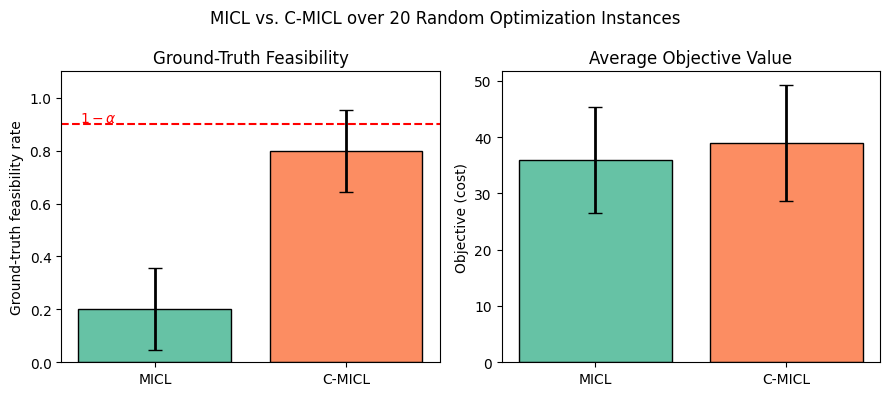

In [10]:
pal = sns.color_palette("Set2", n_colors=2)


def mean_and_ci(s, confidence=0.90, binary=False):
    mean = s.mean()
    sem = np.sqrt(mean * (1 - mean) / len(s)) if binary else s.std() / np.sqrt(len(s))
    ci_low, _ = stats.t.interval(confidence, df=len(s) - 1, loc=mean, scale=sem)
    return mean, mean - ci_low


strategies = ["MICL", "C-MICL"]

feasibility_stats = {
    strategy: mean_and_ci(
        results_df.loc[results_df["strategy"] == strategy, "truly_feasible"],
        binary=True,
    )
    for strategy in strategies
}
objective_stats = {
    strategy: mean_and_ci(
        results_df.loc[results_df["strategy"] == strategy, "objective"]
    )
    for strategy in strategies
}

print("Ground-truth feasibility rate (mean, 90% CI half-width):")
for strategy in strategies:
    print(
        f"  {strategy}: {feasibility_stats[strategy][0]:.3f} "
        f"+/- {feasibility_stats[strategy][1]:.3f}"
    )
print()
print("Average objective / cost (mean, 90% CI half-width):")
for strategy in strategies:
    print(
        f"  {strategy}: {objective_stats[strategy][0]:.3f} "
        f"+/- {objective_stats[strategy][1]:.3f}"
    )

delta_pct = (
    100
    * (objective_stats["C-MICL"][0] - objective_stats["MICL"][0])
    / objective_stats["MICL"][0]
)
print(f"\nC-MICL objective is {delta_pct:.1f}% higher than MICL on average.")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for i, strategy in enumerate(strategies):
    mean, ci = feasibility_stats[strategy]
    axes[0].bar(strategy, mean, color=pal[i], edgecolor="black")
    axes[0].errorbar(strategy, mean, yerr=ci, color="black", capsize=5, lw=2)
axes[0].axhline(1 - alpha, color="red", linestyle="--")
axes[0].text(
    x=0.05,
    y=1 - alpha + 0.01,
    s=r"$1 - \alpha$",
    color="red",
    transform=axes[0].get_yaxis_transform(),
)
axes[0].set_ylabel("Ground-truth feasibility rate")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Ground-Truth Feasibility")

for i, strategy in enumerate(strategies):
    mean, ci = objective_stats[strategy]
    axes[1].bar(strategy, mean, color=pal[i], edgecolor="black")
    axes[1].errorbar(strategy, mean, yerr=ci, color="black", capsize=5, lw=2)
axes[1].set_ylabel("Objective (cost)")
axes[1].set_title("Average Objective Value")

fig.suptitle(f"MICL vs. C-MICL over {iterations} Random Optimization Instances")
plt.tight_layout()
plt.show()

## Discussion

MICL designs reactors that meet the surrogate's point prediction exactly, with no
margin for the surrogate's own error; the printed feasibility rate above shows how
often that margin-free design turns out to be ground-truth feasible once checked
against the ODE oracle $h(x)$. C-MICL instead requires the calibrated lower edge of
the conformal set to meet the target, and is ground-truth feasible far more often as
a result.

The theorem's exact $1-\alpha$ target rests on two conditions, Mondrian conformal
coverage and conditional independence of feasibility and coverage, and on this
notebook's simplified (non-Mondrian) conformal set. How closely these hold in this
particular setting is exactly what determines where the empirical feasibility rate
and its confidence interval land relative to the dashed target line above, whether
short of it, around it, or comfortably containing it. What the result does show,
regardless of where it lands relative to the target, is the *direction and size* of
the effect the theorem predicts: C-MICL's feasibility rate sits much closer to the
target than MICL's, and the gap between the two strategies is large.

The price of that gap is small: the printed objective comparison shows only a modest
increase in average cost for C-MICL. Crucially, this increase is not an arbitrary
safety margin tacked on by hand, it is exactly the calibrated quantile
$\widehat{q}_{1-\alpha}\,\widehat{u}(x)$ learned from data. In summary, this
notebook's empirical evidence is consistent with the C-MICL paper's central claim: a
major increase in ground-truth feasibility for a modest, principled, and
data-driven increase in cost.


## Citation

If this notebook was useful to your work, please cite:

```bibtex
@article{ovalle2026conformal,
  title={Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees},
  author={Ovalle, Daniel and Biegler, Lorenz and Grossmann, Ignacio and Laird, Carl and Dulce Rubio, Mateo},
  journal={Advances in Neural Information Processing Systems},
  volume={38},
  pages={80387--80423},
  year={2026}
}
```
